# Fogler P13-7: Nonisothermal Batch Reactor with Heat Exchange

## Why Are We Learning This?
This exercise demonstrates how reaction kinetics and energy balances are coupled in a nonisothermal batch reactor.

## Learning Objectives
- Design a non-isothermal batch reactor
- Calculate $\Delta H^{rxn}$
- Calculate $\Delta C_P$
- Develop a nonisothermal energy balance
- Solve coupled ODEs using `solve_ivp'
- Compare nonisothermal and isothermal reactor performance

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Problem Data

In [ ]:
CA0=0.1
CPA=0.015
CPB=0.015
CPC=0.030
HfA=-20
HfB=-15
HfC=-41
E=10
kref=0.01
Tref=325
UA=0.010
T0=350
Ta=430
V=10
R=0.001987
NA0=CA0*V
X_target = 0.9

## Heat of Reaction

In [ ]:
DHrxn = HfC-HfA-HfB
print("The Heat of Reaction is ",DHrxn," kcal/mol.")

The Heat of Reaction is  -6  kcal/mol.


## Verify Delta Cp

In [ ]:
DeltaCp = CPC-(CPA+CPB)
print("Delta CP = ",DeltaCp," kcal/mol")

Delta CP =  0.0  kcal/mol


## Arrhenius Equation

In [ ]:
def k(T):
    return kref*np.exp(E/R*(1/Tref-1/T))

## Rate Law

The reaction is:

A + B $\longrightarrow$ C

We are told to use elementary kinetics. Hence:

$$-r_A = kC_AC_B$$

This is a liquid phase reaction, so

$$C_A = C_{A0}(1-X)$$

A & B are present initially in equimolar amounts, so

$$C_B = C_A$$

Hence: $-r_A = kC_{A0}^2(1-X)^2$


In [ ]:
def rA(X,T):
    return -k(T)*CA0**2*(1-X)**2

## Mole Balance

General form: $N_{A0}\frac{dX}{dt}=-r_AV$.

This is a batch reactor, which is usually constant volume, but that's not specified in the problem statement. However, we know that the reaction occurs in liquid phase, making it constant volume regardless of reactor. Hence, V is a constant, which means it is not a function of $X$ or $t$ and hence does not need to be accounted for inside the derivative (or integral). Hence:

$$\frac{dX}{dt} = \frac{-r_A}{C_{A0}} $$

In [ ]:
def dXdt(X,T):
    return -rA(X,T)/CA0

## $\sum_i \Theta_i C_{P,i} $

Recall that

$$\Theta_i = \frac{N_{i,0}}{N_{LR,0}} $$

For this problem: $\Theta_A = 1$, $\Theta_B = 1$, and $\Theta_C = 0$. Hence:

$$\sum_i \Theta_i C_{P,i} = C_{PA} + C_{PB} $$

From the problem statement, $C_{PA} = C_{PB}$, so $\sum_i \Theta_i C_{P,i} = 2C_{PA} $.

From the problem statement, $C_{PC} = 2C_{PA}$, so

$$\sum_i \Theta_i C_{P,i} = C_{PC} $$

## Energy Balance

For a batch reactor in terms of conversion:

$$\frac{dT}{dt} = \frac{(r_A)(\Delta H^{rxn}) + UA(T_a - T)}{N_{A0}\left(\sum_i \Theta_i C_{P,i} + \Delta C_PX\right)} $$

For our case:

$$\frac{dT}{dt} = \frac{(-r_A)(-\Delta H^{rxn}) + UA(T_a - T)}{N_{A0}C_{PC} } $$

In [ ]:
def dTdt(X,T):
    return (UA*(Ta-T)+DHrxn*(rA(X,T)*V))/(NA0*CPC)

## Coupled ODE System

In [ ]:
def batchreactor(t,y):
    X,T=y
    return [dXdt(X,T), dTdt(X,T)]

In [ ]:
tmax = 1000
t_eval=np.linspace(0,tmax,500)
sol=solve_ivp(batchreactor,[0,1000],[0,T0],t_eval=t_eval)
t=sol.t
X=sol.y[0]
T=sol.y[1]

## Conversion versus Time

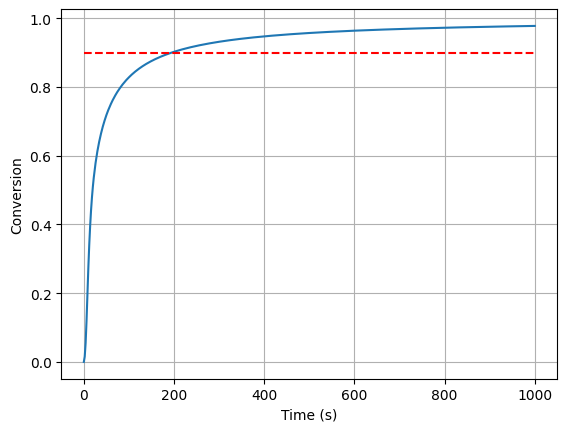

In [ ]:
plt.plot(t,X)
plt.plot(t,np.ones(len(t))*X_target,'r--')
plt.xlabel("Time (s)")
plt.ylabel("Conversion")
plt.grid()
plt.show()

## Temperature versus Time

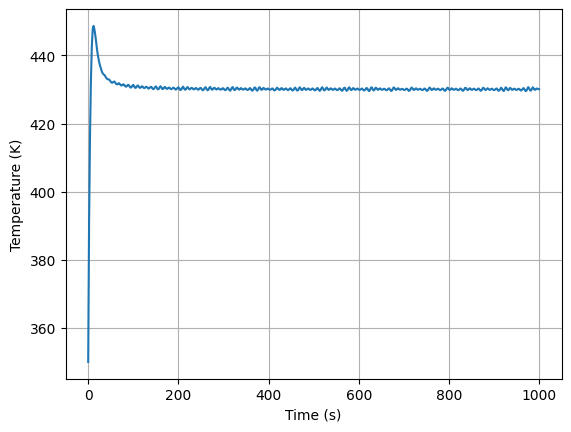

In [ ]:
plt.plot(t,T)
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.grid()
plt.show()

## T and t at Conversion = 90%

In [ ]:
idx=np.argmin(np.abs(X-X_target))
print("Time at X = ",X_target," = ",t[idx], " s.")
print("Temperature at X = ",X_target," = ",T[idx]," K.")

Time at X =  0.9  =  194.3887775551102  s.
Temperature at X =  0.9  =  429.97543379404084  K.


## Isothermal Comparison at 350 K

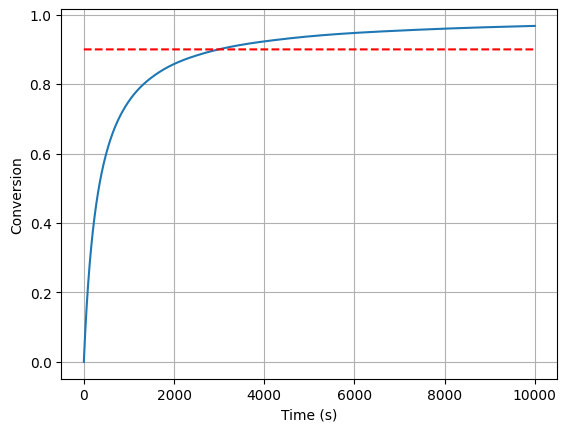

In [ ]:
tmax_iso=10000
t_eval_isoT0=np.linspace(0,tmax_iso,5000)
def isothermal_batchreactor(t,y,T):
    X=y[0]
    return [-(-k(T)*CA0**2*(1-X)**2)/CA0]

sol_isoT0=solve_ivp(isothermal_batchreactor,[0,tmax_iso],[0],t_eval=t_eval_isoT0,args=(T0,))
plt.plot(sol_isoT0.t,sol_isoT0.y[0])
plt.plot(sol_isoT0.t,np.ones(len(sol_isoT0.t))*X_target,'r--')
plt.xlabel("Time (s)")
plt.ylabel("Conversion")
plt.grid()
plt.show()

## T and t at Conversion = 90%

In [ ]:
idx_isoT0=np.argmin(np.abs(sol_isoT0.y[0]-X_target))
print("Time at X = ",X_target," = ",sol_isoT0.t[idx_isoT0], " s.")
print("Temperature at X = ",X_target," = ",T0," K.")

Time at X =  0.9  =  2988.5977195439086  s.
Temperature at X =  0.9  =  350  K.


## Isothermal with T = Ta

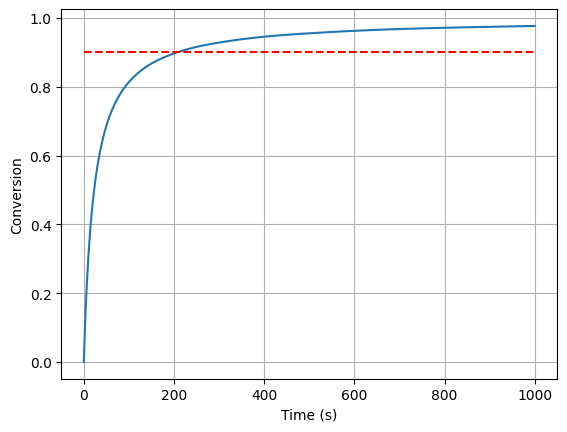

In [ ]:
sol_isoTa=solve_ivp(isothermal_batchreactor,[0,tmax],[0],t_eval=t_eval,args=(Ta,))
plt.plot(sol_isoTa.t,sol_isoTa.y[0])
plt.plot(sol_isoTa.t,np.ones(len(sol_isoTa.t))*X_target,'r--')
plt.xlabel("Time (s)")
plt.ylabel("Conversion")
plt.grid()
plt.show()

## T and t at 90% conversion

In [ ]:
idx_isoTa=np.argmin(np.abs(sol_isoTa.y[0]-X_target))
print("Time at X = ",X_target," = ",sol_isoTa.t[idx_isoTa], " s for isothermal operation with T = Ta and ",t[idx]," s for adiabatic operation.")
print("Modeling as isothermal requires ",sol_isoTa.t[idx_isoTa]/t[idx]," times as much time as modeling as adiabatic operation.")
print("Temperature at X = ",X_target," = ",Ta," K for isothermal operation with T = Ta and ",T[idx]," K for adiabatic operation.")
print("Max temperature for isothermal operation with T = Ta is ",Ta," K while max temperature for adiabatic operation is ",np.max(T)," K.")
print("Max temperature is ",np.max(T)-Ta," K higher for isothermal operation than adiabatic operation.")

Time at X =  0.9  =  206.41282565130257  s for isothermal operation with T = Ta and  194.3887775551102  s for adiabatic operation.
Modeling as isothermal requires  1.0618556701030926  times as much time as modeling as adiabatic operation.
Temperature at X =  0.9  =  430  K for isothermal operation with T = Ta and  429.97543379404084  K for adiabatic operation.
Max temperature for isothermal operation with T = Ta is  430  K while max temperature for adiabatic operation is  448.6870639358804  K.
Max temperature is  18.687063935880417  K higher for isothermal operation than adiabatic operation.
